# Straka Bubble Test 🫧

Welcome to the first $\texttt{PADDLE}$ tutorial! Here, we will demonstrate how to initialize and run the code for dynamical simulations, and processing outputs, by showcasing the Straka bubble test. 
 
The Straka bubble test, developed by [Straka et al. (1993)](https://onlinelibrary.wiley.com/doi/abs/10.1002/fld.1650170103), is a standard benchmark test of non-hydrostatic numerical models. 

The test involves simulating a dense, sinking bubble that collides with a bottom, rigid, boundary layer. The full execution of the code follows the sinking of the bubble, and the resulting density currents/perturbations at the boundary layer. 

The sinking bubble is a perfect introduction for how a nonhydrostatic code, like $\texttt{PADDLE}$, differs from codes that assume hydrostatic equilibrium. In particular, hydrostatic equilibrium assumes that pressure forces balance gravity.

In the sinking bubble case, there is a density perturbation that causes it to break this equilibrium, since it must accelerate and sink. Processes similar to the sinking bubble case occur in planetary atmospheres, where parcels of air can differ in density or temperature from their surrounding environment, causing non-hydrostatic convective motions. 

This test was first applied to $\texttt{SNAP}$ (Simulating Nonhydrostatic Atmospheres on Planets, the underlying numerical simulation solver of $\texttt{PADDLE}$) in [Li et al. (2019)](https://iopscience.iop.org/article/10.3847/1538-4365/aafdaa). It was also applied to $\texttt{CANOE}$ (Comprehensive Atmosphere N' Ocean Engine, another underlying code to $\texttt{PADDLE}$), see this [blog post](https://public.websites.umich.edu/~jihenghu/space/research/canoe-athena/canoe-example-straka/index.html).

Lets get started by setting up the Straka problem!

<img src="../images/2d.straka-theta.png">

<div class="alert alert-block alert-success">

## $\texttt{PADDLE}$ Straka - Run In Terminal 

If you don't want to be bogged down by all the details of the tutorial, here is how to run the entire bubble test in a terminal.

In order to run in terminal: 


1. Open terminal and activate your paddle conda environment
2. cd into the directory storing the straka.yaml and straka.py (/example_py_scripts)
3. Note that in straka.yaml, under $\texttt{distribute}$, nb2 = 2 and nb1 = 1. This means the number of cores you can use for multiprocessing is 2 (nb1 * nb2)
4. Run the following code in terminal (2 = number of cores)
5. pd-run 2 python straka.py
6. Once finished, you'll notice a bundle of .nc files with .out1 in them. This code combines them into a -main.nc 
7. pd-combine 1 -o main
8. Then to view
9. ncview straka-main.nc

</div>

# Problem Set-Up

In simple terms, the Straka problem involves: 

1. **A background 2-dimensional atmosphere that has a constant potential temperature of 300K referenced at 1 bar.**

2. **A parcel of gas (a bubble) is defined, vertically displaced, with a maximum temperature difference of -15K.** 

<div class="alert alert-warning">

$\textbf{Potential Temperature}$ ($\theta$)  is the temperature a parcel of unsaturated (no moisture, also known as 'dry') air in the atmosphere would have if it is moved adiabatically (not losing or gaining any heat to the environment) to a specific pressure. 

In this case, it means that a parcel of dry air in the background atmosphere would have a temperature of 300K at 1 bar (which is, coincidentally, the temperature and surface pressure of Earth). It is defined for an ideal gas as 

$\theta = T(\frac{P_0}{P})^{\frac{R}{c_p}}$

where T is the temperature of the parcel, P is the pressure of the parcel, $P_0$ is the reference pressure (here, 1 bar), R is the specific gas constant of air, and $c_p$ is the specific heat capacity at constant pressure. In our background atmosphere, if a parcel of dry air is brought adiabatically from a pressure P and temperature T to 1 bar, it would be 300K. 

Potential Temperature is a hugely important quantity in dynamical simulations, since it is a conserved quantity for dry adiabatic processes and is useful in determining the atmospheric stability of a parcel of gas.

In particular, if the potential temperature increases with height the atmoshere is stable (vertical motions of parcels are supressed, i.e., stably stratified) and if it decreases with height the atmosphere is unstable and prone to convection (perturbed air parcels with either rise or sink).

</div>

Lets see how to actually set this problem up in $\texttt{PADDLE}$. 

# $\texttt{PADDLE}$ Problem Generation 

In order to use $\texttt{PADDLE}$, one has to set up the problem (the physics behind the problem, either in a .ipynb or .py file) and an initizilation file (.yaml file). 

For initialization, users can either directly edit the .yaml file provided in the example folder and run .py scripts in a terminal (see /example_py_scripts/straka.yaml and straka.py) or can define variables and run code in a jupyter notebook. 

For this demonstration, we will walk through the entire contents of the straka.yaml and straka.py files and run code in this notebook.

<div class="alert alert-block alert-success">

## $\texttt{PADDLE}$ Straka Initilization (Generation of .yaml file)

A .yaml file is, in essence, a dictionary of defined variables. Here, we will generate the dictionary from scratch and convert it into a .yaml file at the end. 

We suggest having the straka.yaml file (located in the /example_py_scripts folder) pulled up while following the tutorial below. 

</div>

<div class="alert alert-info">

### Define Simulation Domain Geometry ($\texttt{geometry}$)

The first dictionary entry in the .yaml file, $\texttt{geometry}$, defines the geometry of the simulation domain. 

The first thing to define is the domain (size and resolution) of the simulation. In this case, its the spatial dimension and resolution of the background atmosphere.  

For our background atmosphere, lets define a 2D atmosphere that is 25.6 kilometers (15 miles) wide and 6.4 km (4 miles) high. 

</div>

In [1]:
# Here we define spatial dimensions 
# Each has a min and max value, defining the cartesian box

# Initialize a cartesian geometry (a box, or a cube)
geometry_type = 'cartesian'

# Spatial Dimensions ('bounds')

# x1 = Height (often denoted with 'z')
x1min = 0
x1max = 6.4e3 # in meters

# x2 = Width (often denoted with 'x')
x2min = 0
x2max = 25.6e3 # in meters

# x3 = Depth (often denoted with 'y')
# While our atmosphere is 2D, we still need to define the depth dimension. 
# Be defining our resolutions, we will ensure the geometry is 2D instead of 3D
# The depth value here is arbritrary
x3min = 0
x3max = 25.6e3

# Spatial Resolutions ('cells')
# Here, we will define the identical vertical and horizontal resolutions

# nx1 = Number of Cells in Height Dimension
nx1 = 64 # 1 cell per 0.1 km 

# nx2 = Number of Cells in Width Dimension 
nx2 = 256 # 1 cell per 0.1 km 

# nx3 = Number of Cells in Depth Dimension 
# Here we want a 2D simulation, so we set this to 1 
nx3 =1 # 1 to reduce simulation to 2D

# nghost = Number of ghost zones
# The ghost zones are additional cells that pad the interior simulation domain 
# I.e. if a simulation is 40x40 it would be 46x46 due to 3 additional cells on each side 
# A good default number here is 3
nghost = 3

Now we actually create the dictionary entry for geometry from the variables above, so we can generate the .yaml file from a dictionary at the end of this section.

In [2]:
geometry_dict = {'type': geometry_type,
                 'bounds': {'x1min': x1min, 'x1max': x1max,
                            'x2min': x2min, 'x2max': x2max, 
                            'x3min': x3min, 'x3max': x3max},
                 'cells':  {'nx1': nx1, 'nx2': nx2, 'nx3': nx3, 'nghost': nghost}}

<div class="alert alert-info">

### Define Dynamics ($\texttt{dynamics}$)

The second dictionary entry, $\texttt{dynamics}$, defines the dynamical properties of the simulation. 

In this context, $\texttt{dynamics}$ means properties like the equation of state type of the atmosphere, as well as defining the algorithms that are utilized to solve the hydrodynamics of the simulation. 

The $\texttt{dynamics}$ dictionary entry is composed of multiple sub-dictionaries, defined below.

</div>

#### Dynamics sub-dictionary: Equation of State Properties 

For our straka bubble case, we will assume the entire atmopshere is an ideal gas. Ideal gases follow the ideal gas law, and all of their state variables (pressure, temperature, volume, internal energy, etc) can be defined entirely by two variables: 

1. The adiabatic index $\gamma$
2. Molecular weight $M$

In future tutorials, we will explore other equation of states included in $\texttt{PADDLE}$. 

In [3]:
# Equation of State (EOS) Properties

# We first must set up the equation of state of the simulation gas. 
# The equation of state is a thermodynamic equation that relates state variables 
# such as pressure, temperature, volume, and internal energy. 

# Here we use the ideal gas law 
# We will discuss other equations of state in other tutorials
eos_type = 'ideal-gas'

# For ideal gases, you only need two variables, the adiabatic index and molecular weight 

# gammad is the adiabatic index
# It is equal to c_p/c_v = C_p/C_v (heat capacity const p/heat capacity const v)
# (note that lowercase c = specific heat capacity [depends on mass], uppercase C = heat capacity)
# The adiabatic index 1.66 for monoatomic gasses (He, Ar) and 1.4 for diatomic gasses (N, O, Air)
gammad = 1.4 

# molecular weight (kg/mol)
# This is the molecular wieight of Earth's atmosphere 
weight = 29.3e-3 # in kg/mol

# Make Sub-Dictionary 
equation_of_state_dict = {'type': eos_type, 'gammad': gammad, 'weight':weight}

#### Dynamics sub-dictionaries: Vertical Projection, Reconstruct, and Riemann Solver Properties 

For this initial tutorial, the following sub-dictionaries of $\texttt{dynamics}$ (which determine different algorithms that are used in the simulation, and therefore numerical stability) can be taken as-is, though we will provide short introductions to the following: 

The $\texttt{vertical-projection}$ defines a numerical method that is used in non-hydrostatic codes. In short, it defines a variable to balance the atmosphere with (since nonhydrostatic codes cannot use pressure as their vertical component to balance by). You can use temperature or entropy, though the default we will use here is temperature. 

The $\texttt{reconstruct}$ properties define the algorithm to compute fluxes across cell boundaries in the simulation from properties like cell averages. Here we use the weno5 (fifth-order accurate weighted essentially nonoscillation) algorithm, which will be stable except in very specific situations (like shocks in ultra Hot Jupiters).

Finelly we have the $\texttt{riemann-solver}$, which solves the hydrodynamic conservation laws. There are two main option: hhlc (Harten-Lax-van Leer-Contact) and lmars (Low Mach number Approximate Riemann Solver). For this case we use LMARS, though actual atmospheric simulations will often use hhlc. 

In [4]:
# Vertical Projection Properties 

# Vertical projection type 
vertical_projection_type = 'temperature'

pressure_margin = 1e-6

# Make Sub-Dictionary 
vertical_projection_dict = {'type': vertical_projection_type,
                            'pressure-margin': pressure_margin
                            }


In [5]:
# Reconstruct Properties 

# Uses the weno5 alogorithm 

# Vertical Reconstruction 
vertical_reconstruct_type = 'weno5'
vertical_reconstruct_scale = False
vertical_reconstruct_shock = False

# Horizontal Reconstruction 
horizontal_reconstruct_type = 'weno5'
horizontal_reconstruct_scale = False
horizontal_reconstruct_shock = False

# Make Sub-Dictionary 
reconstruct_dict = {'vertical'  : {'type' : vertical_reconstruct_type,
                                   'scale': vertical_reconstruct_scale,
                                   'shock': vertical_reconstruct_shock},
                    'horizontal': {'type' : horizontal_reconstruct_type,
                                   'scale': horizontal_reconstruct_scale,
                                   'shock': horizontal_reconstruct_shock}}

In [6]:
# Riemann Solver 

# lmars solver (Low Mach number Approximate Riemann Solver)
# was developed to better capture atmospheric flows and transitions from hydro to non-hydrostatic models
riemann_type = 'lmars'

# Make Sub-Dictionary 
riemann_solver_dict = {'type': riemann_type}

Now we create the dictionary object for the future .yaml file

In [7]:
# Combine the dictionaries above into a larger dynamics dictionary 

dynamics_dict = {'equation-of-state': equation_of_state_dict,
                 'vertical-projection': vertical_projection_dict,
                 'reconstruct': reconstruct_dict,
                 'riemann-solver': riemann_solver_dict}

<div class="alert alert-info">

### Define Boundary Conditions ($\texttt{boundary-condition}$)

The third dictionary entry, $\texttt{boundary-condition}$, defines how waves interact with the boundaries of the simulation domain. 

In particular, there are three main kinds of boundary conditions we can define for each wall of the simulation domain: 

1. Reflecting : This is a solid wall boundary that waves cannot cross. 

2. Periodic : This is a wrapping boundary. I.e., if the right and left walls of the box domain are periodic, waves that hit the right hand side of the domain will appear on the left hand side. That means the simulation domain will be essentially a cylinder, instead of a box. 

3. Outflow: Waves leave the simulation domain forever

The main sub-dictionary we will define here is the $\texttt{external}$ boundary coniditions. There also exists $\texttt{internal}$ boundary coniditions, which defines how waves interact with boundaries inside the simulation domain (like topography), which we will explore in future tutorials simulating rocky planet atmospheres. 

</div>

In [8]:
# External Properties 

# x1 (height) inner and outer properties 
x1_inner = 'reflecting' # Bottom Wall
x1_outer = 'reflecting' # Top Wall

# x2 (width) inner and outer properties 
x2_inner = 'periodic' # Left Wall
x2_outer = 'periodic' # Right Wall

# x3 (depth) inner and outer properties 
x3_inner = 'reflecting' # Towards us Wall
x3_outer = 'reflecting' # Away from us Wall


Now we create the dictionary object for the future .yaml file

In [9]:
boundary_condition_dict = {'external': {'x1-inner': x1_inner,
                                         'x1-outer': x1_outer,
                                         'x2-inner': x2_inner,
                                         'x2-outer': x2_outer,
                                         'x3-inner': x3_inner,
                                         'x3-outer': x3_outer}}

<div class="alert alert-info">

### Define Integration Properties ($\texttt{integration}$)

The fourth dictionary entry, $\texttt{integration}$, determines how time-stepping is solved and handled in the simulation. In particular, it also sets how long a simulation is run for. 

For this tutorial, there is no need to change the interation-specific parameters below, though we will provide an explanation of each here: 

$\texttt{integration-type}$ is a third-order Runge-Kutta method ('rk3'). This is the default integration type, and there are not too many reasons to change this. 

$\texttt{cfl}$ is the Courant-Friedrich-Lewy number which determines the stability of the time-stepping scheme. It is the the ratio of how far a wave/particle can travel in a single time step vs the local cell size. You want this number to be between 0.5-1, where a cfl larger than 1 means information travels more than one cell in a time step.

$\texttt{implicit-scheme}$ determines which Vertical-Implicit correction (VIC) scheme is used. While not important for the straka case where the vertical and horizontal resolutions are the same, usually atmospheric simulations have a large aspect ratio between horizontal and vertical directions that causes the integration time step to be limited by vertical motions. The first implementation of VIC in $\texttt{SNAP}$ can be found in [Ge et al. (2020)](https://iopscience.iop.org/article/10.3847/1538-4357/ab9ec7/pdf). In future tutorials, we will explore different options here (0 = everything is explicit, 1 = simplified vertical implicit for cartesian cases, and 9 = full vertical implicit for cubed-sphere simulations).

</div>

In [10]:
# Integration properties 

# Integration type is a third-order Runge-Kutta method
integration_type = 'rk3'

# cfl = stability condition (Courant-Friedrich-Lewy number)
cfl = 0.9

# implicit_scheme 
# This is tied to the idea of Vertical-Implicit correction schemes
# 0 = everything explicit 
implicit_scheme = 0

Here we define properties that determine how long a simulation runs and how often diganostic information is printed out. 

There are two important distinctions to be made: 

1. $\texttt{cycles}$: A cycle is an integration step, where the simulation time that has elapsed (dt) is determined in part by the cfl number above. 

2. $\texttt{time}$: Time here is the number of seconds that have elapsed in the simulation, not amount of time that has elapsed in real life. 

In [11]:
# nlim 
# Number of cycles to run model 
# -1 = run until time limit
nlim = -1 

# How long we want the simulation to run before it terminates
# Here, we set it at 900 seconds
tlim = 900

# ncycle_out 
# frequency of printing out diagnostic information to terminal 
# cycle = integration step
ncycle_out = 10

Now we create the dictionary object for the future .yaml file

In [12]:
integration_dict = {'type': integration_type,
                    'cfl': cfl,
                    'implicit-scheme': implicit_scheme,
                    'nlim': nlim,
                    'tlim': tlim,
                    'ncycle_out':10}

<div class="alert alert-info">

### Define Forcing ($\texttt{forcing}$ )

The fifth dictionary entry, $\texttt{forcing}$, defines what deviates the simulation from its initial equilibrium state. In general, all simulations will include constant (with height) gravity. We will explore other forcings in future tutorials. 

</div>

In [13]:
# Forcing properties 
# Here, we only have the 'const-gravity' sub-dictionary 

# Gravity in the x1 (height) direction
gravity_1 = -9.8 # in m/s^2

Now we create the dictionary object for the future .yaml file

In [14]:
forcing_dict = {'const-gravity': {'grav1': gravity_1}}

<div class="alert alert-info">

### Define Initial Problem Conditions ($\texttt{problem}$)

The sixth dictionary entry, $\texttt{problem}$, sets up the actual properties of the bubble in the simulation, and the atmosphere surrounding it (i.e., the 'free variables' of the simulation). 

In order to do this, we have to get a bit creative and find a mathematical way to define the bubble's initial coniditions. 

The bubble itself is defined by its spatial dimensions and temperature distribution. 

</div>

#### Bubble's spatial intialization

Here, we define an elliptical-shaped bubble whose center is at the coordinate (0 km, 3 km) (where will take 0 is the 'x'/width coordinate, and 3 is the 'z'/height coordinate). 

In $\texttt{PADDLE}$, height is the first dimension defined in the $\texttt{geometry}$ section above (x1) while width is the second dimension (x2). 

For its actual size, lets define the bubble be to extend 4 km right and left of the center, and 2 km up and down of the center.

By definition, the bubble will exist wherever the elliptical distance $L$ is $<1$, where 

$L = ((\frac{x-x_c}{x_r})^2+(\frac{z-z_c}{z_r})^2)^{1/2}$

where x_c and z_c are the center coordinate of the bubble, and x_r and z_r are the maximum left/right up/down distance from the bubble's center.

Lets plot what this looks like in practice.

Text(0, 0.5, 'Simulation Vertical Extent (km, x1, z)')

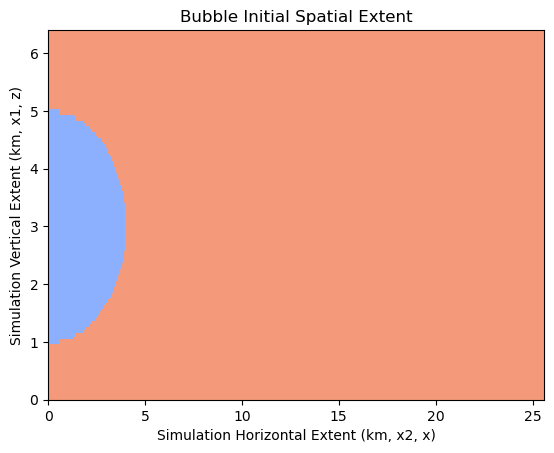

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Center of the bubble is at 0, 3 km
zc = 3e3 # height of center, in meters
xc = 0   # left/right of center, in meters

# Maximum distance up/down,left/right,  from center of bubble 
zr = 2e3 # up/down from center, in meters
xr = 4e3 # left/right from center, in meters

# Lets plot the bubble's spatial extent 

# Simulation domain as defined in Domain Geometry cell above
# Note that x1 (z) in that cell is height 
# and that x2  (x) is the width 
z_array = np.linspace(x1min, x1max, nx1)
x_array = np.linspace(x2min, x2max, nx2)

# Create meshgrid in order to plot 
Z, X = np.meshgrid(z_array, x_array)

# Elliptical distance 
L = ((((X-xc)/xr)**2) + (((Z-zc)/zr)**2))**0.5

# Add the mask L < 1 (which defines the spatial extent of the bubble)
# Divide X and Z by 1000 to get km instead of m 
plt.contourf(X/1000,Z/1000, L < 1, cmap = 'coolwarm_r')
plt.title('Bubble Initial Spatial Extent')
plt.xlabel('Simulation Horizontal Extent (km, x2, x)')
plt.ylabel('Simulation Vertical Extent (km, x1, z)')

#### Bubble's temperature anomaly intialization

We will then define some sort of temperature distribution so that the maximum temperature difference will be -15K of the surrounding atmosphere. The following definition ensures theres a sort of gradient of temperature anomaly: 

$\Delta T = -15K \frac{cos(\pi L) + 1}{2} \; ; \; L < 1$

The temperature difference between the bubble and its surrounding atmosphere, $\Delta T$, is known as the temperature anomaly. 

Lets plot what this looks like: 

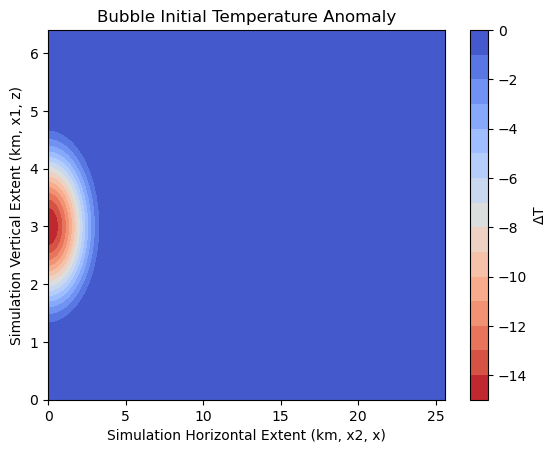

In [16]:
# Maximum temperature difference from surrounding atmosphere
dT = -15 # in Kelvin 

# Temperature anomaly 
# Where L<1 (within bounds of bubble) compute delta_T, otherwise, delta_T = 0
delta_T = np.where(L < 1, dT*((np.cos(np.pi*L) + 1)/2), 0)

# Plot with delta_T as colormap 
plt.contourf(X/1000,Z/1000, delta_T, cmap = 'coolwarm_r', levels = np.linspace(-15,0,16))
plt.title(r'Bubble Initial Temperature Anomaly')
plt.xlabel('Simulation Horizontal Extent (km, x2, x)')
plt.ylabel('Simulation Vertical Extent (km, x1, z)')
plt.colorbar(label = r'$\Delta$T')

#### Deriving initial temperature, pressure, and density of simulation domain

Since we defined the background atmosphere as an ideal gas, the simulation as adiabatic, and we know a specific pressure-temperature point (1 bar = 300K), we can derive the full initial condition of the atmosphere (for more complex atmospheres, $\texttt{PADDLE}$ can compute initial conditions, which we will explore in future tutorials)

The dry adiabatic lapse rate (i.e., how temperature changes with altitude) for an ideal gas is 

$\frac{dT}{dz} = -\frac{g}{c_p}$ 

where the units are

$\frac{K}{m} = \frac{m/s^2}{J/K\cdot kg} = \frac{m/s^2}{(kg \cdot m^2/s^2)/K\cdot kg}$

For an ideal gas under adiabatic conditions, we can get the specific heat capacity (constant pressure) via 

$c_p = \frac{\gamma R}{\gamma -1} = \frac{\gamma}{\gamma -1}\frac{8.314 \; J/mol\cdot K}{M}$

where $\gamma$ is the adiabatic index, R is the specific gas constant (= universal gas constant/molecular weight), and M is the molecular weight defined in the $\texttt{dynamics}$ dictionary

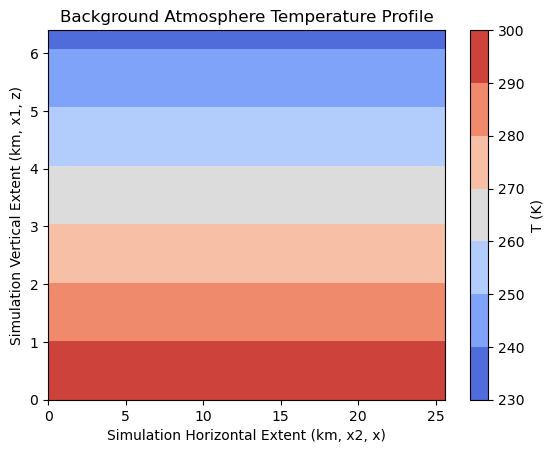

In [17]:
# Specific heat capacity (const pressure) for ideal gas
c_p = (gammad/(gammad-1))*(8.314/weight)

# Dry adiabatic lapse rate for ideal gas
# Note that gravity_1 is already negative 
# So we remove the '-' sign 
dT_dz = gravity_1/c_p # K per m 

# Initial condition 
# Surface temperature is 300K 
Ts = 300

# T = Initial Tempearture + (lapse rate * altitude array)
T_array = 300 + (dT_dz*Z)

# Plot temperature w/ height 
plt.contourf(X/1000,Z/1000, T_array, cmap = 'coolwarm', levels = np.linspace(230,300,8))
plt.title(r'Background Atmosphere Temperature Profile')
plt.xlabel('Simulation Horizontal Extent (km, x2, x)')
plt.ylabel('Simulation Vertical Extent (km, x1, z)')
plt.colorbar(label = r'T (K)')

We can now apply the temperature anomaly of the bubble to the atmosphere

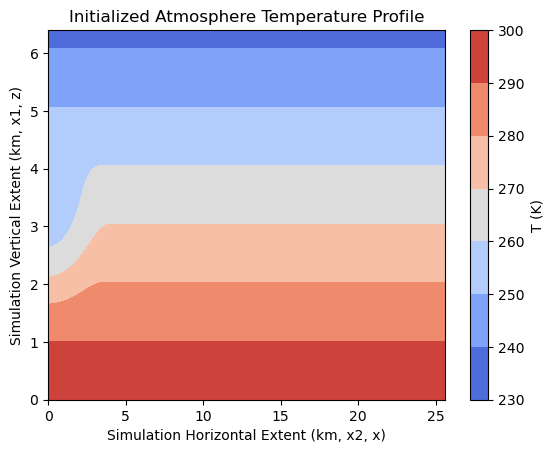

In [18]:
# Temperature array + temperature anomaly array 
plt.contourf(X/1000,Z/1000, T_array + delta_T, cmap = 'coolwarm', levels = np.linspace(230,300,8))
plt.title(r'Initialized Atmosphere Temperature Profile')
plt.xlabel('Simulation Horizontal Extent (km, x2, x)')
plt.ylabel('Simulation Vertical Extent (km, x1, z)')
plt.colorbar(label = r'T (K)')

We can also convert altitude to pressure, and get initial density. 

To convert from altitude to pressure:

$P = P_0(1-\frac{h}{T_0}\frac{g}{c_p})^\frac{\gamma}{\gamma -1}$

where h is the altitude, and $P_0$ and $T_0$ are some known P and T, which we take to be the surface temperature (Ts) and pressure (p0). 

In nonhydrostatic simulations, it is natural to take altitude as the vertical coordinate instead of pressure since pressure is a variable controlled by dynamics (instead of from hydrostatic balance).

And finally, the density is given by 

$\rho = \frac{P}{T}\frac{M}{8.314 \; J/mol\cdot K}$

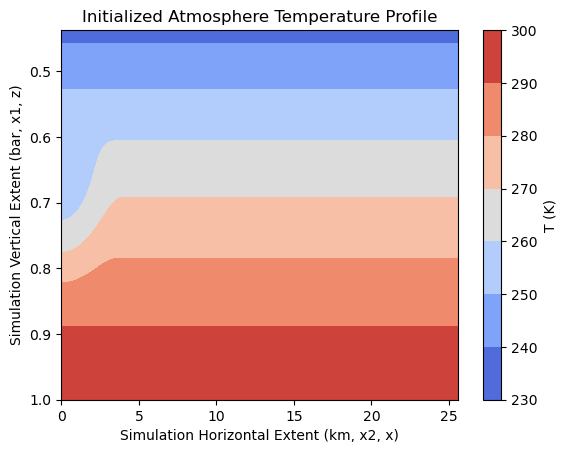

In [19]:
# p0 is the surface pressure
# 1 bar = 1e5 pascals 
p0 = 1e5

# Note that gravity_1 is negative so we flip the sign here 
P = p0*(1-((Z/Ts)*(-gravity_1/c_p)))**(gammad/(gammad-1))

# Plot pressure in bars on y-axis
plt.contourf(X/1000,P/1e5, T_array + delta_T, cmap = 'coolwarm',levels = np.linspace(230,300,8))
plt.gca().invert_yaxis()
plt.title(r'Initialized Atmosphere Temperature Profile')
plt.xlabel('Simulation Horizontal Extent (km, x2, x)')
plt.ylabel('Simulation Vertical Extent (bar, x1, z)')
plt.colorbar(label = r'T (K)')

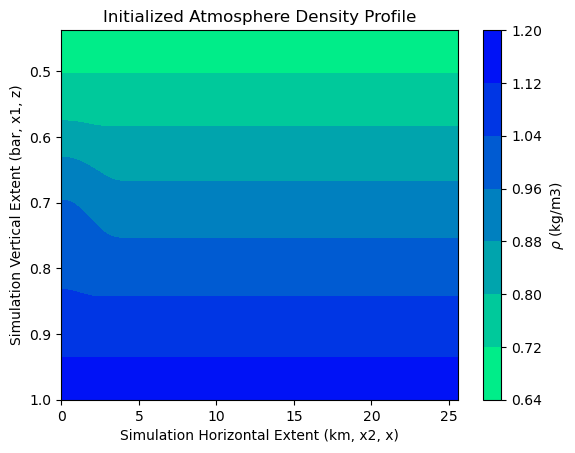

In [20]:
# Solve for air density
density = (P/(T_array+delta_T))*(weight/8.314)

# Plot
plt.contourf(X/1000,P/1e5, density, cmap = 'winter_r',)
plt.gca().invert_yaxis()
plt.title(r'Initialized Atmosphere Density Profile')
plt.xlabel('Simulation Horizontal Extent (km, x2, x)')
plt.ylabel('Simulation Vertical Extent (bar, x1, z)')
plt.colorbar(label = r'$\rho$ (kg/m3)')

Great! So we have a good idea how our bubble is set up before we let it drop. 

The actual physics we discussed above will be used to set up the actual python code we use to run the simulation. Here, we just repeat the free variables that will be used to intialize the spatial and physical properties of the bubble and surrounding atmosphere. 

In [21]:
# Define the problem's free parameters

# p0 is the surface pressure
# 1 bar = 1e5 pascals 
p0 = 1e5 # in pascals

# surface temperature 
Ts = 300 # in K 

# Horizontal coordinate for center of bubble 
xc = 0 # in m 

# Horizontal extent of bubble
xr = 4e3 # in m

# Vertical coordinate for center of bubble
zc = 3e3 # in m

# Vertical extent of bubble
zr = 2e3 # in m

# Maximum temperature anomaly 
dT = -15 

# K is the kinematic viscosity
# This free parameter is only used here in straka in order to benchmark with original paper
# So no need to pay this variable any heed
K = 75

Now we create the dictionary object for the future .yaml file

In [22]:
problem_dict = {'p0': p0,
                'Ts': Ts,
                'xc': xc,
                'xr': xr,
                'zc': zc,
                'zr': zr,
                'dT': dT,
                'K': K}

<div class="alert alert-info">

### Define Distribute Properties ($\texttt{distribute}$)

The seventh dictionary enetry, $\texttt{distribute}$, describes how parallel computing is accomplished (and therefore only important for running py scripts in termainl). We will still go over the properties here since it will be pertinent later in the tutorial: 

</div>

In [23]:
# Two choices for backend
# 'gloo' for CPU parallel computing
# 'nccl' for GPU
backend = 'gloo'

# Two choices for layout 
# 'slab' for cartesian environments 
# 'cubed-sphere' for 3D spheres 
layout = 'slab'

# nb2 and nb3 are the number of blocks in each dimension
# These two numbers determine the amount of cores you can use 
# For slab layouts, number of cores = nb2 * nb1
# For jupyter notebooks, we can only use 1 core in a cell 
# We will go over multi-core processing more explicitly at the end of this notebook
nb2 = 1
nb3 = 1

# vebose 
# Running the code will always produce time-stepping outputs to terminal
# The verbose here is explicitly for printing out information useful for debugging
verbose = False

Now we create the dictionary object for the future .yaml file

In [24]:
# Make Dictionary 
distribute_dict = { 'backend': backend,
                    'layout': layout,
                    'nb2': nb2,
                    'nb3': nb3,
                    'verbose': verbose}

<div class="alert alert-info">

### Define Outputs ($\texttt{outputs}$)

The final dictionary entry, $\texttt{outputs}$, determines what sorts of files are produced by the simulation. This portion is extremely important to define carefully, as it determines how often outputs are produced and what sort of variables are saved for future analysis. 

When you run $\texttt{PADDLE}$ code, two sorts of files will be produced. 

1. Restart files: These files (denoted by .restart) will be produced every $\texttt{dt-restart}$ (in simulation time). These files can be used to restart a simulation from a specific 'checkpoint' and are essential when running larger simulations (where computers can time out). 

2. Netcdf progress files: These files are produced every $\texttt{dt-netcdf}$ (in simulation time). They store all the variables defined in $\texttt{variables-track}$. Once a simulation has finished, these files can be combined into a single .nc file and are deleted. Below, we define that we want to track primitive variables ($\texttt{prim}$) which includes (for straka) density, pressure, and velocities in the three directions (v1-v3). We also can define user output variables ($\texttt{uov}$) which are defined explicitly when we create our $\texttt{PADDLE}$ execution code. 

</div>

In [25]:
# Output properties 

# Two different kind of output files. Restart files, and netcdf progress files

# How often we want .restart files to be generated
# Here, we define a restart file to be generated every 300 simulations seconds
# Resulting in a total of 5 restart files at 0, 300, 600, and 900 seconds 
# (and an additional final one at t_lim = 900s)
dt_restart = 300

# Then we define how often we generate .nc files that track specific variables
# We first define which variables we want to be track 
# prim = primitave variables
# For straka, density, three velocities (v1-v3), pressure
# uov = user output variable (Athena++ nomenclature) 
# tied to call_user_output in py scrpt
variables_track = ['prim','uov']

# Then we define how often we want the files to be generated 
# Here, its every 30 simulation seconds
# These output files are then compressed into a single nc file that 
# can be analyzed
dt_netcdf = 30

Now we create the dictionary object for the future .yaml file

In [26]:
outputs_dict = [{'type': 'restart', 'dt': dt_restart},
               {'type': 'netcdf', 'variables' : variables_track, 'dt': dt_netcdf}]

### Create the input .yaml file 

Here, we generate the .yaml file from the dictionaries we defined above. If you have the straka.yaml pulled up, you'll notice how we have been following the structure of that file in this notebook here. 

In this notebook, we explictly generate the input .yaml file from dictionaries defined in this jupyter notebook. However, in the future, we can just edit a .yaml file directly (additionally, the .yaml file found in /example_py_scripts should be more human readable than the one we generate here).

In [28]:
import yaml

full_dictionary = {'geometry': geometry_dict,
                   'dynamics': dynamics_dict,
                   'boundary-condition': boundary_condition_dict,
                   'integration': integration_dict,
                   'forcing': forcing_dict,
                   'problem': problem_dict,
                   'distribute': distribute_dict,
                   'outputs': outputs_dict,}


file_path = "testing.yaml"
with open(file_path, "w") as file_handler:
    yaml.dump(full_dictionary, file_handler, sort_keys=False)

<div class="alert alert-block alert-success">

## $\texttt{PADDLE}$ Straka Physics (Generation of py script)

Now that we have completely set up the straka problem from scratch, we can now actually run the code! 

In general, with $\texttt{PADDLE}$, users will rarely have to generate their own .py scripts to run simulations based on examples covered in tutorial notebooks, However, more advanced users might want to develop their own scripts, so we provide comments on the script below. Also, in general $\texttt{PADDLE}$ is a python-wrapper for codes like [$\texttt{kintera}$](https://github.com/chengcli/kintera) and [$\texttt{snap}$](https://github.com/chengcli/snapy), so for actual details for the thermodynamics and dynamical codes, look there. 

We reccomend having the straka.py script, found in /example_py_scripts, open while we go through the next few cells below. 

For those just wanting to drop the bubble, just run the next few cells! 

</div>

Import necessary packages

In [29]:
import torch
import math
import kintera
from snapy import MeshBlockOptions, MeshBlock
from snapy import kIDN, kIPR

Generate the call_user_output function 

As mentioned in the $\texttt{outputs}$ section above, the output files can include user output variables (uov). These user output variables are defined in a function called **call_user_output()**. 

Here, we are outputing both temperature and potential temperature. 

In [30]:
def call_user_output(bvars):

    # Load in the variables stored by the simulation 
    hydro_w = bvars["hydro_w"]

    # Create a user output variable dictionary 
    out = {}

    # Compute temperature from 
    # kIPR = Pressure (defined below)
    # kIDN = Density  (defined below)
    # Rd = specific gas constant (defined below)
    # Therefore, 
    # T = Pressure/(R*Density)
    # Potential temperature = T * (p0/P)^(R_cp)
    
    temp = hydro_w[kIPR] / (Rd * hydro_w[kIDN])
    out["temp"] = temp
    out["theta"] = temp * (p0 / hydro_w[kIPR]).pow(Rd / cp)
    return out

Load in the initial problem variables

Note that even though we included these variables in the yaml file, they are not pulled out explicitly in the script since they are unique to each problem. 

Therefore, we pull them out here. 

In [31]:
p_0 = full_dictionary['problem']['p0']
T_s = full_dictionary['problem']['Ts']
xc  = full_dictionary['problem']['xc']
xr  = full_dictionary['problem']['xr']
zc  = full_dictionary['problem']['zc']
zr  = full_dictionary['problem']['zr']
dT  = full_dictionary['problem']['dT']
K   = full_dictionary['problem']['K']

TO DO: Go through and add details to this cell

In [32]:
# Define the device (here its a cpu, since we are running it in a Jupyter notebook)
# cuda is for gpu computation 
if torch.cuda.is_available():
    device = torch.device("cuda:0")
else:
    device = torch.device("cpu")

# set hydrodynamic options from our yaml file
op = MeshBlockOptions.from_yaml("testing.yaml")

# initialize block
block = MeshBlock(op)
block.to(device)

# get handles to modules
coord = block.module("coord")
eos = block.module("hydro.eos")
grav = -block.options.hydro().grav().grav1()

# thermodynamics
Rd = kintera.constants.Rgas / eos.options.weight()
cv = eos.species_cv_ref()
cp = cv + Rd

# setup a meshgrid for simulation
x3v, x2v, x1v = torch.meshgrid(
    coord.buffer("x3v"), coord.buffer("x2v"), coord.buffer("x1v"), indexing="ij"
)

# dimensions
nc3 = coord.buffer("x3v").shape[0]
nc2 = coord.buffer("x2v").shape[0]
nc1 = coord.buffer("x1v").shape[0]
nvar = 5

w = torch.zeros((nvar, nc3, nc2, nc1), device=device)

L = torch.sqrt(((x2v - xc) / xr) ** 2 + ((x1v - zc) / zr) ** 2)
temp = Ts - grav * x1v / cp

w[kIPR] = p0 * torch.pow(temp / Ts, cp / Rd)
temp += torch.where(L <= 1, dT * (torch.cos(L * math.pi) + 1.0) / 2.0, 0)
w[kIDN] = w[kIPR] / (Rd * temp)

block_vars = {}
block_vars["hydro_w"] = w
block_vars, current_time = block.initialize(block_vars)

block.set_user_output_func(call_user_output)

# integration
block.make_outputs(block_vars, current_time)

while not block.intg.stop(block.inc_cycle(), current_time):
    dt = block.max_time_step(block_vars)
    block.print_cycle_info(block_vars, current_time, dt)

    for stage in range(len(block.intg.stages)):
        block.forward(block_vars, dt, stage)

    err = block.check_redo(block_vars)
    if err > 0:
        continue  # redo current step
    if err < 0:
        break  # terminate

    current_time += dt
    block.make_outputs(block_vars, current_time)

block.finalize(block_vars, current_time)


[HydroOptions] -- constant gravity options --
* grav1 = -9.8
* grav2 = 0
* grav3 = 0
cycle=10 redo=0 time=2.34819714277236e+00 dt=2.60910784247350e-01 mass0=3.76823726405015e+12 energy=7.24829775220409e+17
cycle=20 redo=0 time=4.95727292510746e+00 dt=2.60893577737861e-01 mass0=3.76823726405015e+12 energy=7.24834317103303e+17


[W129 15:18:52.631645000 ProcessGroupGloo.cpp:757] Warning: Unable to resolve hostname to a (local) address. Using the loopback address as fallback. Manually set the network interface to bind to with GLOO_SOCKET_IFNAME. (function operator())


cycle=30 redo=0 time=7.56579110506572e+00 dt=2.60769097958819e-01 mass0=3.76823726405015e+12 energy=7.24841932094857e+17
cycle=40 redo=0 time=1.01724414737450e+01 dt=2.60531328373894e-01 mass0=3.76823726405015e+12 energy=7.24851470702780e+17
cycle=50 redo=0 time=1.27768102850956e+01 dt=2.60343816314116e-01 mass0=3.76823726405015e+12 energy=7.24860618534184e+17
cycle=60 redo=0 time=1.53798868284640e+01 dt=2.60282066326661e-01 mass0=3.76823726405014e+12 energy=7.24867412010068e+17
cycle=70 redo=0 time=1.79825602255767e+01 dt=2.60240072591037e-01 mass0=3.76823726405014e+12 energy=7.24871185495890e+17
cycle=80 redo=0 time=2.05846393053706e+01 dt=2.60166429274826e-01 mass0=3.76823726405014e+12 energy=7.24871896677538e+17
cycle=90 redo=0 time=2.31859429219158e+01 dt=2.60085496075097e-01 mass0=3.76823726405014e+12 energy=7.24869564282981e+17
cycle=100 redo=0 time=2.57864222590868e+01 dt=2.60003075346612e-01 mass0=3.76823726405014e+12 energy=7.24864221441008e+17
cycle=110 redo=0 time=2.8386181

Now the directory you ran this notebook in will have the following files: 

1. testing.0000X.restart (X ranging from 0 to 3), and testing.final.restart
2. testing.out1.XXXXX.nc (XXXXXX ranging from 00000-00030)

Now we will combine the out1.nc files with the following terminal command

pd-combine 1 -o 'name_of_output_file'

The '1' here corresponds to out1. In future simulations, we might have out1, out2, and out3. Here, we would run 

pd-combine 1,2,3 -o 'name_of_output_file'

In [ ]:
!pd-combine 1 -o main

# Doesn't work in notebook but does work in py terminal. Look into this issue?

OMP: Error #15: Initializing libomp.dylib, but found libomp.dylib already initialized.
OMP: Hint This means that multiple copies of the OpenMP runtime have been linked into the program. That is dangerous, since it can degrade performance or cause incorrect results. The best thing to do is to ensure that only a single OpenMP runtime is linked into the process, e.g. by avoiding static linking of the OpenMP runtime in any library. As an unsafe, unsupported, undocumented workaround you can set the environment variable KMP_DUPLICATE_LIB_OK=TRUE to allow the program to continue to execute, but that may cause crashes or silently produce incorrect results. For more information, please see http://openmp.llvm.org/


After which, you'll have a file called 'straka-main.nc' and all the out1.nc files will have dissapeared. Now, we can look at the simulation results!

<div class="alert alert-block alert-success">

## $\texttt{PADDLE}$ Straka - Analyze Output

Once you have the combined straika-main.nc, there are two ways by which to analyze the outputs. The first is using $\texttt{ncview}$ via terminal commands in the Jupyter notebook, and the second is by loading in the nc file itself. We will show both here. 

</div>

<div class="alert alert-info">

### $\texttt{ncview}$

Below, we can use terminal commands in the Jupyter notebook by typing '!' before the command. 

Here we will use $\texttt{ncview}$ (see **Installation** for how to install), which is a great tool for a quick look at our simulation's results. 

Checkout the next figure for how to use some of the ncview features. To exit out, just press the 'x' in the top left.

</div>

<img src="../images/ncview-tutorial-straka.png">

In [ ]:
!ncview straka-main.nc

Ncview 2.1.8 David W. Pierce  8 March 2017
http://meteora.ucsd.edu:80/~pierce/ncview_home_page.html
Copyright (C) 1993 through 2015, David W. Pierce
Ncview comes with ABSOLUTELY NO WARRANTY; for details type `ncview -w'.
This is free software licensed under the Gnu General Public License version 3; type `ncview -c' for redistribution details.

Note: no Ncview app-defaults file found, using internal defaults
calculating min and maxes for press...
calculating min and maxes for temp...
X connection to /private/tmp/com.apple.launchd.vqTSVEtnvy/org.xquartz:0 broken (explicit kill or server shutdown).


<div class="alert alert-info">

### Load in the nc file

Loading the .nc file directly in a notebook, while a bit more tedious than using $\texttt{ncview}$, is useful for when you will want to (inevitably) analyze your simulations outputs in more detail (and make figures).

</div>

In [ ]:
import netCDF4
import numpy as np

# Open the file
straka_output = netCDF4.Dataset('straka-main.nc', 'r')

# Print the dimensions
# x1 is the coordinate of cell centers while x1f is cell boundaries (length is 1 longer)
print(straka_output.dimensions.keys())

# Print the stored variables
print(straka_output.variables.keys())

# Lets plot the temperature 
data_temperature = straka_output.variables['temp'][:]

# 31 frames
# 64 cells by 1 cell by 256 cells
print(np.shape(data_temperature))


dict_keys(['time', 'x1', 'x1f', 'x2', 'x2f', 'x3'])
dict_keys(['time', 'x1', 'x1f', 'x2', 'x2f', 'x3', 'rho', 'press', 'vel1', 'vel2', 'vel3', 'temp', 'theta'])
(31, 64, 1, 256)


For another quick look (without worrying about converting cells to spatial dimension, and frame to time), we can look at the following: 

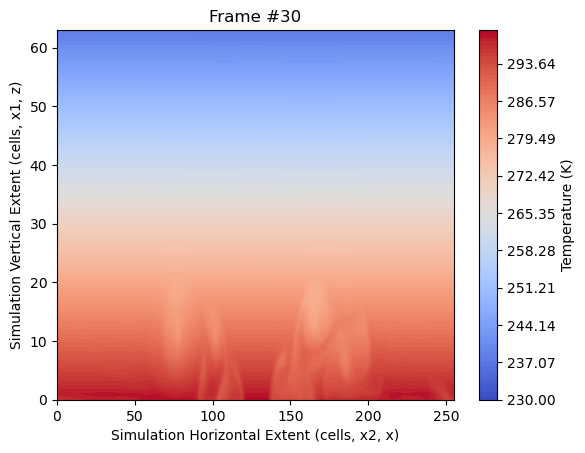

In [ ]:
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

# Loop over the time saved frames 
for t in range(np.shape(data_temperature)[0]):

    # Ensures that the last plot will be cleared 
    clear_output(wait = True)

    # Make a countour plot with really fine layers to capture eddies
    plt.contourf(data_temperature[t,:,0,:], cmap = 'coolwarm', levels = np.linspace(230,300,100))
    plt.colorbar(label = 'Temperature (K)')
    title = 'Frame #' + str(t)
    plt.title(title)
    plt.xlabel('Simulation Horizontal Extent (cells, x2, x)')
    plt.ylabel('Simulation Vertical Extent (cells, x1, z)')
    plt.show()

    # Delay, so that it doesn't go too fast 
    time.sleep(0.1)

Now, lets actually look at the physical units 

In [ ]:
# Array of time for each frame, in seconds
data_time = straka_output.variables['time'][:]

# Array of center of cells for vertical direction
data_x1 = straka_output.variables['x1'][:]

# Array of center of cells for horizontal direction
data_x2 = straka_output.variables['x2'][:]

# Create meshgrid in order to plot 
Z, X = np.meshgrid(data_x2, data_x1)

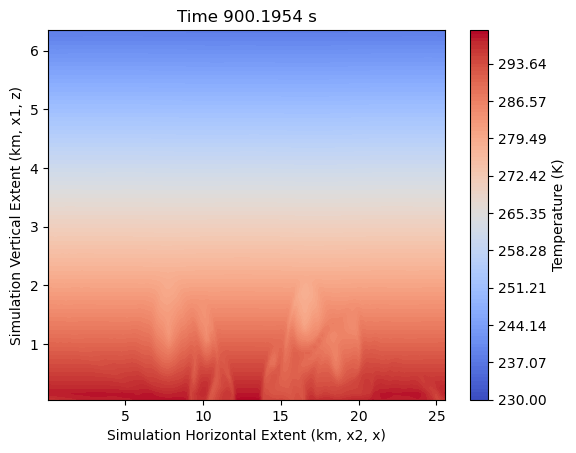

In [ ]:
# Loop over the time saved frames 
for t in range(np.shape(data_temperature)[0]):

    # Ensures that the last plot will be cleared 
    clear_output(wait = True)

    # Make a countour plot with really fine layers to capture eddies
    plt.contourf(Z/1000,X/1000,data_temperature[t,:,0,:], cmap = 'coolwarm', levels = np.linspace(230,300,100))
    plt.colorbar(label = 'Temperature (K)')
    title = 'Time ' + str(data_time[t]) + ' s'
    plt.title(title)
    plt.xlabel('Simulation Horizontal Extent (km, x2, x)')
    plt.ylabel('Simulation Vertical Extent (km, x1, z)')
    plt.show()

    # Delay, so that it doesn't go too fast 
    time.sleep(0.1)

<div class="alert alert-block alert-success">

## $\texttt{PADDLE}$ Straka - Changing Input

Now that we are familiar with the above code, try changing the initial parameters!

Here, we have pre-made a bubble with the following properties: 

Same pressure and temperature for background bubble

p0 = 1e5 

Ts = 300 

Larger bubble placed near center of simulation

xc = 13e3 

xr = 6e3 

zc = 4e3

zr = 3e3 

A bit colder 

dT = -20

K = 75

</div>

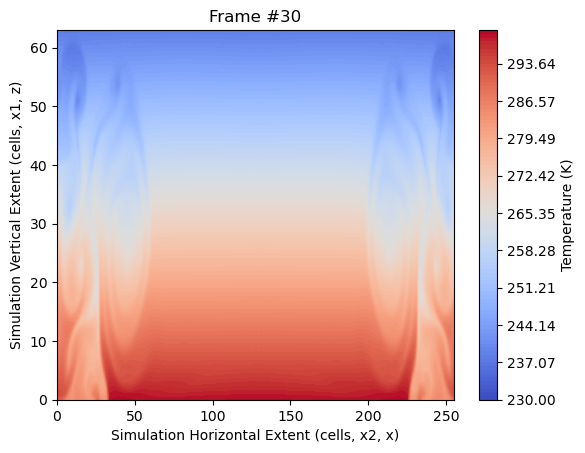

In [ ]:
import netCDF4
import numpy as np

# Open the file
straka_output = netCDF4.Dataset('straka-changing-input.nc', 'r')

# Lets plot the temperature 
data_temperature = straka_output.variables['temp'][:]

import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

# Loop over the time saved frames 
for t in range(np.shape(data_temperature)[0]):

    # Ensures that the last plot will be cleared 
    clear_output(wait = True)

    # Make a countour plot with really fine layers to capture eddies
    plt.contourf(data_temperature[t,:,0,:], cmap = 'coolwarm', levels = np.linspace(230,300,100))
    plt.colorbar(label = 'Temperature (K)')
    title = 'Frame #' + str(t)
    plt.title(title)
    plt.xlabel('Simulation Horizontal Extent (cells, x2, x)')
    plt.ylabel('Simulation Vertical Extent (cells, x1, z)')
    plt.show()

    # Delay, so that it doesn't go too fast 
    time.sleep(0.1)